In [1]:
from pathlib import Path
from pprint import pprint

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from presp.prescriptor import NNPrescriptor, NNPrescriptorFactory
from scipy.stats import spearmanr
import torch
import yaml

# from examples.constraints.context.utils import Experimenter

In [2]:
from constraints.constraint_prescriptor import ConstraintPrescriptor
from constraints.problems import BNH, Circle, Triangle

class Experimenter:
    def __init__(self, results_dir: Path):
        with open(results_dir / "config.yml", "r", encoding="utf-8") as f:
            self.config = yaml.safe_load(f)

        if self.config["problem"] == "triangle":
            self.evaluator = Triangle(**self.config["eval_params"])
            self.factory = NNPrescriptorFactory(ConstraintPrescriptor, **self.config["prescriptor_params"])
        elif self.config["problem"] == "circle":
            self.evaluator = Circle(**self.config["eval_params"])
            self.factory = NNPrescriptorFactory(NNPrescriptor, **self.config["prescriptor_params"])
        elif self.config["problem"] == "bnh":
            self.evaluator = BNH(**self.config["eval_params"])
            self.factory = NNPrescriptorFactory(ConstraintPrescriptor, **self.config["prescriptor_params"])
        else:
            raise ValueError("Problem not supported")
        
        self.population = self.factory.load_population(results_dir / "population")
        self.results_dir = results_dir

        self.results_df = pd.read_csv(self.results_dir / "results.csv")

    def get_gen_df(self, gen: int, pareto: bool = True) -> pd.DataFrame:
        gen_df = self.results_df[self.results_df["gen"] == gen]
        if pareto:
            gen_df = gen_df[gen_df["rank"] == 1]
        return gen_df

    def get_candidate_solutions(self, cand_id: str, contexts: torch.Tensor = None) -> torch.Tensor:
        candidate = self.population[cand_id]
        if contexts is None:
            contexts = self.evaluator.contexts
        actions, _, _ = self.evaluator.prescribe_and_predict(candidate, contexts)
        return actions

    def compute_hypervolume_2d(self, pareto_front: np.ndarray, ref_point: np.ndarray, ideal: np.ndarray) -> float:
        """
        Assumes minimization.
        Pareto front is n x 2
        """
        hypervolume = 0
        pareto_front = np.sort(pareto_front, axis=0)
        for i in range(pareto_front.shape[0]):

            x1 = pareto_front[i, 0]
            if i == pareto_front.shape[0] - 1:
                x2 = ref_point[0]
            else:
                x2 = pareto_front[i+1, 0]

            y1 = pareto_front[i, 1]
            y2 = ref_point[1]

            volume = (x2 - x1) * (y2 - y1)
            volume = max(volume, 0)
            hypervolume += volume

        total_volume = (ref_point[0] - ideal[0]) * (ref_point[1] - ideal[1])
        hypervolume /= total_volume

        return hypervolume

In [3]:
RESULTS_DIR = Path("results/bnh-constrained-longer")
with open(RESULTS_DIR / "config.yml", "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)
results_df = pd.read_csv(RESULTS_DIR / "results.csv")
GENS = results_df["gen"].max()

experimenter = Experimenter(RESULTS_DIR)

pprint(config)

{'eval_params': {'device': 'mps', 'n_jobs': -1},
 'evolution_params': {'mutation_factor': 0.2,
                      'mutation_rate': 0.2,
                      'n_elites': 0,
                      'n_generations': 1000,
                      'population_size': 200,
                      'remove_population_pct': 0,
                      'save_path': 'results/bnh-constrained-longer'},
 'prescriptor_params': {'device': 'mps',
                        'model_params': [{'in_features': 4,
                                          'out_features': 16,
                                          'type': 'linear'},
                                         {'type': 'relu'},
                                         {'in_features': 16,
                                          'out_features': 16,
                                          'type': 'linear'},
                                         {'type': 'relu'},
                                         {'in_features': 16,
                          

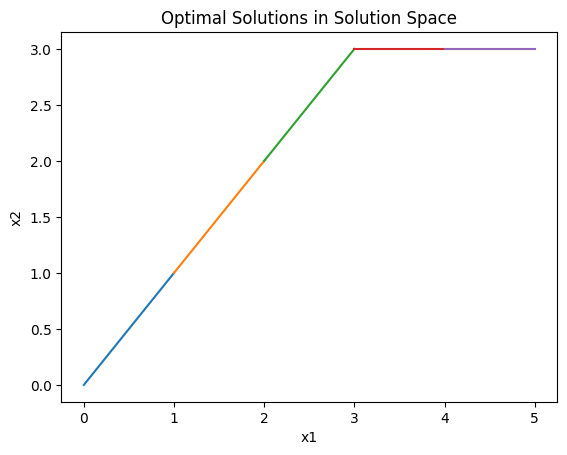

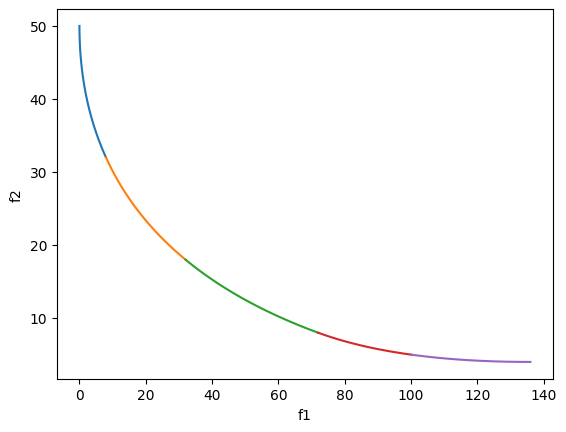

In [4]:
optimal_actions = experimenter.evaluator.get_optimal()

fig, ax = plt.subplots()
for optimal_actions_c in optimal_actions:
    ax.plot(optimal_actions_c[:, 0], optimal_actions_c[:, 1])
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("Optimal Solutions in Solution Space")
plt.show()

for point in optimal_actions:
    # plt.plot(point[:, 0], point[:, 1])
    optimal_outcomes = experimenter.evaluator.compute_outcomes(None, point)
    plt.plot(optimal_outcomes[:, 0], optimal_outcomes[:, 1])
plt.xlabel("f1")
plt.ylabel("f2")
plt.show()

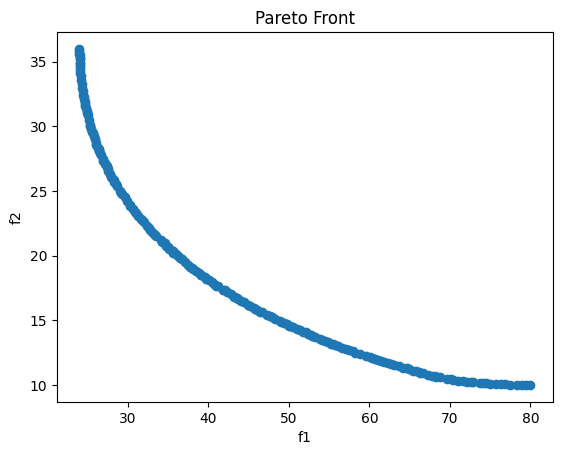

In [5]:
def plot_pareto(plot_optimal: bool = False):
    pareto_df = experimenter.get_gen_df(GENS)
    fig, ax = plt.subplots()
    ax.scatter(pareto_df["f1"], pareto_df["f2"])

    if plot_optimal:
        optimal_actions = experimenter.evaluator.get_optimal()
        for optimal_actions_context in optimal_actions:
            optimal_outcomes = experimenter.evaluator.compute_outcomes(None, optimal_actions_context)
            ax.plot(optimal_outcomes[:, 0], optimal_outcomes[:, 1])
    
    ax.set_xlabel("f1")
    ax.set_ylabel("f2")
    ax.set_title("Pareto Front")
    plt.show()

plot_pareto(False)

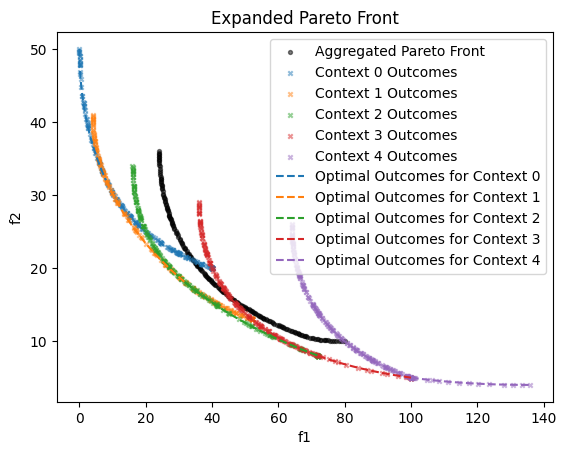

Bad pipe message: %s [b'\x9d\x81\xb5\xed\xd1\x1fU\xfe\x03T\x14\xa2D\x93\xde\xd1|\xf2\x00\x01|\x00\x00\x00\x01\x00\x02\x00\x03\x00\x04\x00\x05']
Bad pipe message: %s [b'\xf2 \xdaYp\x0e7\xcb\xdd']
Bad pipe message: %s [b'\xabS\xbdS\xc8', b'']
Bad pipe message: %s [b'\xbe']
Bad pipe message: %s [b'\xe7\xd9\t._\xd1\xdf7\xe16Kq]\xc5y\x00\x01|\x00\x00\x00\x01\x00\x02\x00\x03\x00\x04\x00\x05\x00\x06\x00\x07\x00\x08\x00\t\x00\n\x00\x0b\x00\x0c\x00\r\x00\x0e\x00\x0f\x00\x10\x00\x11\x00\x12\x00\x13\x00\x14\x00\x15\x00\x16\x00\x17\x00\x18\x00\x19\x00\x1a\x00\x1b\x00/\x000\x001\x002\x003\x004\x005\x006\x007\x008\x009\x00:\x00;\x00<\x00=\x00>\x00?\x00@\x00A\x00B\x00C\x00D\x00E\x00F\x00g\x00h\x00i\x00j\x00k\x00l\x00m\x00\x84\x00\x85\x00\x86\x00', b"\x88\x00\x89\x00\x96\x00\x97\x00\x98\x00\x99\x00\x9a\x00\x9b\x00\x9c\x00\x9d\x00\x9e\x00\x9f\x00\xa0\x00\xa1\x00\xa2\x00\xa3\x00\xa4\x00\xa5\x00\xa6\x00\xa7\x00\xba\x00\xbb\x00\xbc\x00\xbd\x00\xbe\x00\xbf\x00\xc0\x00\xc1\x00\xc2\x00\xc3\x00\xc4\x00\xc5\x1

In [ ]:
def plot_expanded_pareto():
    fig, ax = plt.subplots()
    pareto_df = experimenter.get_gen_df(GENS)

    ax.scatter(pareto_df["f1"], pareto_df["f2"], color="black", label="Aggregated Pareto Front", alpha=0.5, s=8)

    per_context_outcomes = [[] for _ in range(experimenter.evaluator.contexts.shape[0])]
    for cand_id in pareto_df["cand_id"]:
        cand_actions = experimenter.get_candidate_solutions(cand_id)
        cand_outcomes = experimenter.evaluator.compute_outcomes(None, cand_actions).cpu().numpy()
        for context_idx in range(cand_outcomes.shape[0]):
            # cand_outcomes[context_idx] is tuple of (f1, f2)
            per_context_outcomes[context_idx].append(cand_outcomes[context_idx])

    # per_context_outcomes is N x pop_size x 2

    for context_idx, context_outcomes in enumerate(per_context_outcomes):
        # context_outcomes is pop_size x 2 now
        context_outcomes = np.stack(context_outcomes, axis=0)
        ax.scatter(context_outcomes[:, 0], context_outcomes[:, 1], color=f"C{context_idx}", s=10, alpha=0.5, marker="x", label=f"Context {context_idx} Outcomes")

    optimal_actions = experimenter.evaluator.get_optimal()
    for context_idx, optimal_actions_context in enumerate(optimal_actions):
        optimal_outcomes = experimenter.evaluator.compute_outcomes(None, optimal_actions_context)
        ax.plot(optimal_outcomes[:, 0], optimal_outcomes[:, 1], linestyle="--", label=f"Optimal Outcomes for Context {context_idx}")

    ax.set_xlabel("f1")
    ax.set_ylabel("f2")
    ax.set_title("Expanded Pareto Front")
    ax.legend()

    plt.show()

plot_expanded_pareto()

In [7]:
def sample_optimal_pareto_agg(n_points: int = 100):
    pareto_df = experimenter.get_gen_df(GENS)
    per_context_outcomes = [[] for _ in range(experimenter.evaluator.contexts.shape[0])]
    for cand_id in pareto_df["cand_id"]:
        cand_actions = experimenter.get_candidate_solutions(cand_id)
        cand_outcomes = experimenter.evaluator.compute_outcomes(None, cand_actions).cpu().numpy()
        for context_idx in range(cand_outcomes.shape[0]):
            # cand_outcomes[context_idx] is tuple of (f1, f2)
            per_context_outcomes[context_idx].append(cand_outcomes[context_idx])
    per_context_outcomes = np.array(per_context_outcomes)
    
    pareto = []
    for i in range(n_points):
        agg_outcomes = []
        for context_idx, context_outcomes in enumerate(per_context_outcomes):
            # context_outcomes is pop_size x 2
            # draw a random pair of outcomes
            rand_idx = np.random.randint(0, context_outcomes.shape[0])
            agg_outcomes.append(context_outcomes[rand_idx])
        # agg_outcomes is N x 2
        # take the mean to get a simulated pareto point
        agg_outcomes = np.array(agg_outcomes)
        agg = np.mean(agg_outcomes, axis=0)
        pareto.append(agg)
    pareto = np.array(pareto)
    
    return pareto

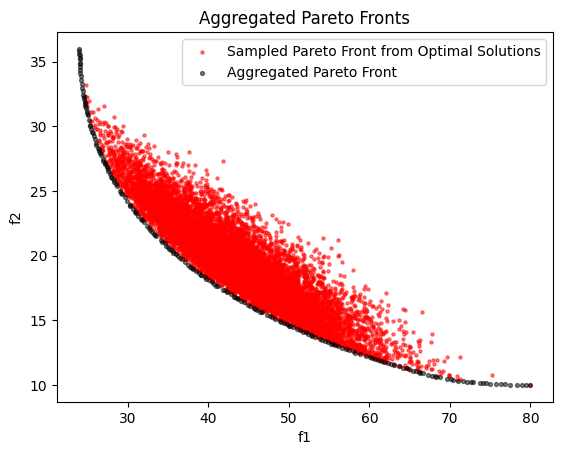

In [8]:
def plot_agg_paretos():
    pareto_df = experimenter.get_gen_df(GENS)
    fig, ax = plt.subplots()

    sample_pareto = sample_optimal_pareto_agg(10000)
    ax.scatter(sample_pareto[:, 0], sample_pareto[:, 1], color="red", label="Sampled Pareto Front from Optimal Solutions", alpha=0.5, s=5)

    ax.scatter(pareto_df["f1"], pareto_df["f2"], color="black", label="Aggregated Pareto Front", alpha=0.5, s=8)

    ax.set_title("Aggregated Pareto Fronts")
    ax.set_xlabel("f1")
    ax.set_ylabel("f2")
    ax.legend()

    plt.show()

plot_agg_paretos()

In [10]:
def plot_hypervolume():
    optimal_actions = experimenter.evaluator.get_optimal()
    optimal_outcomes = experimenter.evaluator.compute_outcomes(experimenter.evaluator.contexts, optimal_actions)
    ref_point = torch.max(optimal_outcomes, dim=0).values
    ref_point = ref_point.cpu().numpy()
    ideal = np.array([0, 0])
    optimal_hypervolume = experimenter.compute_hypervolume_2d(optimal_outcomes, ref_point, ideal)

    hypervolumes = []
    for gen in range(1, GENS + 1):
        gens_df = experimenter.get_gen_df(gen)
        pareto_front = gens_df[["f1", "f2"]].values
        hypervolume = experimenter.compute_hypervolume_2d(pareto_front, ref_point, ideal)
        hypervolume /= optimal_hypervolume
        hypervolumes.append(hypervolume)
    
    fig, ax = plt.subplots()
    ax.plot(range(1, GENS + 1), hypervolumes)

    ax.set_xlabel("Generation")
    ax.set_ylabel("Prop of optimal hypervolume")
    plt.show()

# plot_hypervolume()

In [11]:
def plot_solution_space(ax: plt.Axes, context_idx: int, gen: int, color_idx: int, plot_optimal: bool = True):

    pareto_df = experimenter.get_gen_df(gen, pareto=True)

    all_X = []
    for cand_id in pareto_df["cand_id"]:
        # X: N x C
        X = experimenter.get_candidate_solutions(cand_id).cpu().numpy()
        # all_X: P x C
        all_X.append(X[context_idx])
    all_X = np.stack(all_X)
    x1s = all_X[:, 0]
    x2s = all_X[:, 1]

    label = context_idx
    ax.scatter(x1s, x2s, label=label, color=f"C{color_idx}")

    if plot_optimal:
        optimal = experimenter.evaluator.get_optimal().cpu().numpy()
        optimal = optimal[context_idx]
        ax.plot(optimal[:, 0], optimal[:, 1], color=f"C{color_idx}", linestyle="--")
    return ax

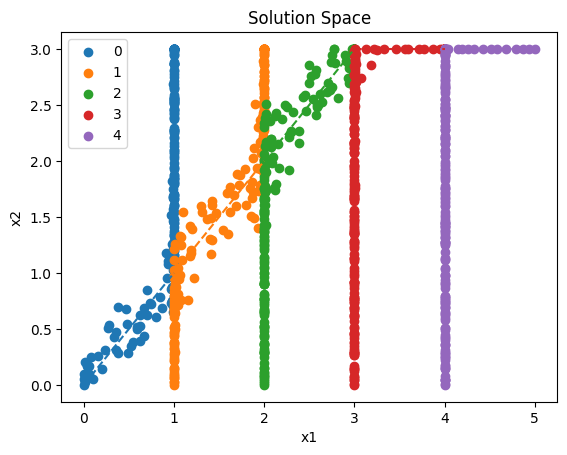

In [12]:
fig, ax = plt.subplots()
for context_idx in range(experimenter.evaluator.contexts.shape[0]):
    ax = plot_solution_space(ax, context_idx, GENS, context_idx, True)

ax.legend()
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("Solution Space")

plt.show()

In [37]:
def get_ranking_df() -> pd.DataFrame:
    pareto_df = experimenter.get_gen_df(GENS, pareto=True)
    cand_outcomes_df = []
    for cand_id in pareto_df["cand_id"]:
        cand_actions = experimenter.get_candidate_solutions(cand_id)
        cand_outcomes = experimenter.evaluator.compute_outcomes(None, cand_actions)
        for context_idx, outcomes in enumerate(cand_outcomes):
            row = {"cand_id": cand_id, "context_idx": context_idx, "f1": outcomes[0].item(), "f2": outcomes[1].item()}
            cand_outcomes_df.append(row)
    cand_outcomes_df = pd.DataFrame(cand_outcomes_df)

    # For each context, sort cand_ids by x1 and record their places. Then sort by x2 and record their places.
    cand_outcomes_df["f1_rank"] = -1
    cand_outcomes_df["f2_rank"] = -1
    for context_idx in range(cand_outcomes_df["context_idx"].max() + 1):
        df = cand_outcomes_df[cand_outcomes_df["context_idx"] == context_idx]
        df = df.sort_values(by=["f1"])
        df["f1_rank"] = np.arange(len(df))
        df = df.sort_values(by=["f2"])
        df["f2_rank"] = np.arange(len(df))
        cand_outcomes_df.loc[cand_outcomes_df["context_idx"] == context_idx, "f1_rank"] = df["f1_rank"]
        cand_outcomes_df.loc[cand_outcomes_df["context_idx"] == context_idx, "f2_rank"] = df["f2_rank"]

    return cand_outcomes_df

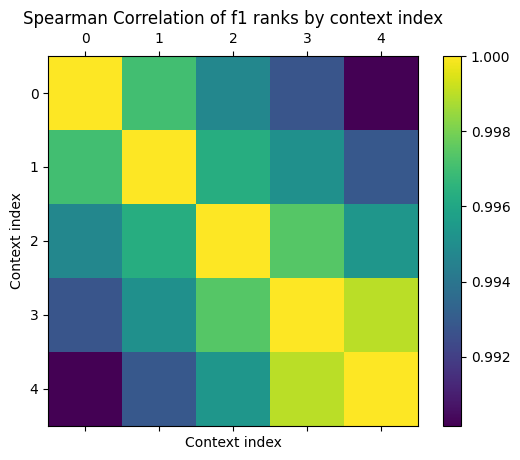

In [38]:
cand_outcomes_df = get_ranking_df()
n_contexts = cand_outcomes_df["context_idx"].max() + 1
spearmans = np.zeros((n_contexts, n_contexts))
for i in range(n_contexts):
    for j in range(n_contexts):
        rank1 = cand_outcomes_df[cand_outcomes_df["context_idx"] == i]["f1_rank"]
        rank2 = cand_outcomes_df[cand_outcomes_df["context_idx"] == j]["f1_rank"]
        spearmans[i, j] = spearmanr(rank1, rank2)[0]

fig, ax = plt.subplots()
cax = ax.matshow(spearmans, cmap="viridis")
ax.set_xlabel("Context index")
ax.set_ylabel("Context index")
ax.set_title("Spearman Correlation of f1 ranks by context index")
plt.colorbar(cax)
plt.show()